# Coupled EI convergence

This notebook follows the numerical relaxation time of the quasiparticle occupations, the excitonic gap, and the band imbalance. It imports the helper functions from `ei_open_loop.py`. The time associated with the mean-field updates is a numerical relaxation time unless `td` and `tm` have been derived from a microscopic dynamical model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from tqdm.auto import tqdm, trange

from ei_open_loop import cur, diag, fd, gam_db, lim_dt, mk_gam, sc

set1_list = list(plt.get_cmap("Set1").colors)

In [2]:
def trace(x, ea, eb, g, n, gs, d=0.1, m=0.0, uh=0.0, n0=1.0,
          dt=1.0, td=0.2, tm=0.2, nmax=20000, tol=1.0e-7,
          keep=10, show=20, par=None):
    """Run coupled partial relaxation and retain its convergence history."""
    n = np.asarray(n, dtype=float).copy()
    ta = []
    da = []
    ma = []
    na = []
    ia = []
    eda = []
    ema = []
    ena = []
    era = []
    tt = 0.0

    bar = trange(nmax, desc="EI relaxation", unit="step")
    for it in bar:
        e, u, v = diag(ea, eb, d, m, uh=uh, n0=n0)
        st = {
            "x": x, "e": e, "u": u, "v": v, "n": n,
            "d": d, "m": m, "par": par,
        }
        r = mk_gam(gs, st)
        dn = cur(n, r)
        h = lim_dt(n, dn, dt)

        if h <= 0.0:
            raise RuntimeError("the occupation step collapsed to zero")

        n = np.clip(n + h * dn, 0.0, 1.0)
        ds, ms, nt = sc(n, u, v, g)

        zd = 1.0 - np.exp(-h / td)
        zm = 1.0 - np.exp(-h / tm)
        d = d + zd * (ds - d)
        m = m + zm * (ms - m)
        tt = tt + h

        ei = np.max(np.abs(dn))
        ed = abs(ds - d)
        em = abs(ms - m)
        en = abs(nt - n0)
        er = max(ei, ed, em, en)

        if it % keep == 0 or er < tol:
            ta.append(tt)
            da.append(d)
            ma.append(m)
            na.append(n.copy())
            ia.append(ei)
            eda.append(ed)
            ema.append(em)
            ena.append(en)
            era.append(er)

        if it % show == 0:
            bar.set_postfix(d=f"{d:.4e}", m=f"{m:.4e}", err=f"{er:.2e}")

        if er < tol:
            bar.set_postfix(d=f"{d:.4e}", m=f"{m:.4e}", err=f"{er:.2e}")
            break

    return {
        "t": np.asarray(ta),
        "d": np.asarray(da),
        "m": np.asarray(ma),
        "n": np.asarray(na),
        "i": np.asarray(ia),
        "ed": np.asarray(eda),
        "em": np.asarray(ema),
        "en": np.asarray(ena),
        "err": np.asarray(era),
        "nf": n,
        "df": d,
        "mf": m,
        "ok": er < tol,
        "it": it + 1,
    }

The following cell defines the asymmetric EI bands and two bath callbacks. Replace `gs` with any other gamma callbacks that follow the existing rate-tensor interface.

In [3]:
nk = 51
x = (np.arange(nk) + 0.5) / nk
gg = -0.4
rr = 0.7
ea = 0.5 * gg + x
eb = -0.5 * gg - rr * x

g = 1.5
uh = 0.5
n0 = 1.0
d0 = 0.2
m0 = 0.0
t1 = 0.12
t2 = 0.35

e0, _, _ = diag(ea, eb, d0, m0, uh=uh, n0=n0)
n = fd(e0, t=max(t1, t2), n0=n0)

gs = [
    gam_db(t=t1, c=0.3, wc=2.0),
    gam_db(t=t2, c=0.3, wc=2.0),
]

In [4]:
z = trace(
    x, ea, eb, g, n, gs,
    d=d0, m=m0, uh=uh, n0=n0,
    dt=1.0, td=0.2, tm=0.2,
    nmax=20000, tol=1.0e-7,
    keep=10, show=20,
)

print(f"ok={z['ok']} it={z['it']} err={z['err'][-1]:.3e}")
print(f"Delta={z['df']:.8f} m={z['mf']:.8f}")

EI relaxation:   0%|          | 0/20000 [00:00<?, ?step/s]

ok=False it=20000 err=6.246e-03
Delta=0.62146573 m=-0.39264766


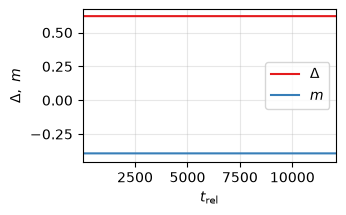

In [5]:
fig, ax = plt.subplots(figsize=(3.47412, 0.65 * 3.47412))
ax.plot(z["t"], z["d"], color=set1_list[0], label=r"$\Delta$")
ax.plot(z["t"], z["m"], color=set1_list[1], label=r"$m$")
ax.set_xlabel(r"$t_{\mathrm{rel}}$")
ax.set_ylabel(r"$\Delta,\ m$")
ax.set_xlim(z["t"][0], z["t"][-1])
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
ep = 1.0e-16
fig, ax = plt.subplots(figsize=(3.47412, 0.72 * 3.47412))
ax.semilogy(z["t"], np.maximum(z["i"], ep), color=set1_list[0],
            label=r"$\lVert I\rVert_\infty$")
ax.semilogy(z["t"], np.maximum(z["ed"], ep), color=set1_list[1],
            label=r"$|\Delta_{\mathrm{sc}}-\Delta|$")
ax.semilogy(z["t"], np.maximum(z["em"], ep), color=set1_list[2],
            label=r"$|m_{\mathrm{sc}}-m|$")
ax.semilogy(z["t"], np.maximum(z["en"], ep), color=set1_list[3],
            label=r"$|n_0-1|$")
ax.set_xlabel(r"$t_{\mathrm{rel}}$")
ax.set_ylabel(r"$\mathrm{residual}$")
ax.set_xlim(z["t"][0], z["t"][-1])
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left",
          mode="expand", borderaxespad=0, ncol=2)
plt.tight_layout()
plt.show()

ValueError: 
\lVert I\rVert_\infty
^
ParseFatalException: Unknown symbol: \lVert, found '\'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x7f64e8a42d40> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
\lVert I\rVert_\infty
^
ParseFatalException: Unknown symbol: \lVert, found '\'  (at char 0), (line:1, col:1)

ValueError: 
\lVert I\rVert_\infty
^
ParseFatalException: Unknown symbol: \lVert, found '\'  (at char 0), (line:1, col:1)

<Figure size 347.412x250.137 with 1 Axes>

Plotting snapshots:   0%|          | 0/6 [00:00<?, ?curve/s]

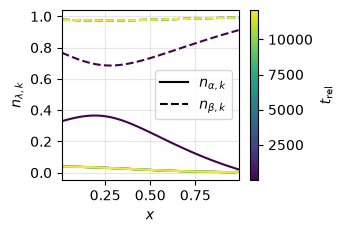

In [7]:
ids = np.unique(np.linspace(0, z["t"].size - 1, 6).astype(int))
norm = Normalize(vmin=z["t"][ids].min(), vmax=z["t"][ids].max())
cmap = plt.get_cmap("viridis")
sm = ScalarMappable(norm=norm, cmap=cmap)

fig, ax = plt.subplots(figsize=(3.47412, 0.70 * 3.47412))
for j in tqdm(ids, desc="Plotting snapshots", unit="curve"):
    col = cmap(norm(z["t"][j]))
    ax.plot(x, z["n"][j, 0], color=col, ls="-")
    ax.plot(x, z["n"][j, 1], color=col, ls="--")

ax.plot([], [], color="black", ls="-", label=r"$n_{\alpha,k}$")
ax.plot([], [], color="black", ls="--", label=r"$n_{\beta,k}$")
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"$t_{\mathrm{rel}}$", rotation=90, labelpad=5)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$n_{\lambda,k}$")
ax.set_xlim(x[0], x[-1])
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()